# Spring 2025-2026 CS 412 Recitation 12: Semi & Unsupervised Learning on News Text

## 0. Setup

In [37]:
!pip install -q datasets gensim

In [38]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from datasets import load_dataset
from gensim.models import Word2Vec

RANDOM_STATE = 42
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

## 1. Load & Prepare AG News

Same dataset as last week: 4 topic categories, short news articles.
We take a balanced subset of 3,000 articles per class (12,000 total).

In [39]:
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"} # from the dataset documentation

ag_news = load_dataset("ag_news")

train_df_full = pd.DataFrame(ag_news["train"])
test_df_full  = pd.DataFrame(ag_news["test"])

train_df_full["label_name"] = train_df_full["label"].map(label_map)
test_df_full["label_name"]  = test_df_full["label"].map(label_map)

def balanced_sample(df, label_col, n_per_class, random_state):
    parts = []
    for label in sorted(df[label_col].unique()):
        group = df[df[label_col] == label]
        parts.append(group.sample(n=min(n_per_class, len(group)), random_state=random_state))
    return pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

train_df = balanced_sample(train_df_full, "label_name", 3000, RANDOM_STATE)
test_df  = balanced_sample(test_df_full,  "label_name",  750, RANDOM_STATE)

print("Training set:", train_df.shape)
print("Testing set: ", test_df.shape)
print()
print(train_df["label_name"].value_counts())

Training set: (12000, 3)
Testing set:  (3000, 3)

label_name
Business    3000
Sports      3000
World       3000
Sci/Tech    3000
Name: count, dtype: int64


In [40]:
train_df_full.head()

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [41]:
for category in train_df_full["label_name"].unique():
    sample = train_df_full[train_df_full["label_name"] == category].iloc[0]
    print(f"Category: {category}")
    print(sample["text"])
    print()

Category: Business
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Category: Sci/Tech
'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 2005" came out that day,\and some fans of the football simulation are rabid enough to\take a sick day to play it.

Category: Sports
Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenband and teammate Klete Keller were faster than the teenager in the 200 free preliminaries.

Category: World
Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezue

## 2. Build Word2Vec Vectors

Same pipeline as last week: tokenize each article, train Word2Vec, then average the word vectors into one vector per article.

In [42]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text) # replaces anything that is not a letter or space with a space
    return text.split()

X_train_tokens = [tokenize(t) for t in train_df["text"]]
X_test_tokens  = [tokenize(t) for t in test_df["text"]]

print("Example article:")
print(train_df["text"].iloc[0])
print()
print("Tokenized:")
print(X_train_tokens[0])

Example article:
Timing Is Everything   Here's just what you need: another complication involving individual retirement accounts.

Tokenized:
['timing', 'is', 'everything', 'here', 's', 'just', 'what', 'you', 'need', 'another', 'complication', 'involving', 'individual', 'retirement', 'accounts']


In [43]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,          # Skip-Gram
    negative=5,
    epochs=15,
    seed=RANDOM_STATE
)

print("Vocabulary size:", len(w2v_model.wv))
print("Vector dimension:", w2v_model.vector_size)

Vocabulary size: 11918
Vector dimension: 100


In [44]:
def article_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train = np.array([article_vector(t, w2v_model) for t in X_train_tokens])
X_test  = np.array([article_vector(t, w2v_model) for t in X_test_tokens])
y_train = train_df["label_name"].values
y_test  = test_df["label_name"].values

print("Training matrix shape:", X_train.shape)
print("Testing matrix shape: ", X_test.shape)

Training matrix shape: (12000, 100)
Testing matrix shape:  (3000, 100)


## 3. The Label Scarcity Problem

We have 12,000 articles and their vectors are ready.

But now imagine we only had the budget to label 5% of them.
That leaves us with 600 labelled articles and 11,400 unlabelled ones.

Let's first see how badly a classifier trained on just 600 examples performs.

In [45]:
LABEL_FRACTION = 0.05

np.random.seed(RANDOM_STATE)
n_labelled = int(len(X_train) * LABEL_FRACTION)

labelled_idx   = np.random.choice(len(X_train), n_labelled, replace=False)
unlabelled_idx = np.array([i for i in range(len(X_train)) if i not in set(labelled_idx)])

X_labelled   = X_train[labelled_idx]
y_labelled   = y_train[labelled_idx]
X_unlabelled = X_train[unlabelled_idx]
y_unlabelled = y_train[unlabelled_idx]

print("Labelled examples:  ", len(X_labelled))
print("Unlabelled examples:", len(X_unlabelled))

Labelled examples:   600
Unlabelled examples: 11400


In [46]:
clf_weak = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_weak.fit(X_labelled, y_labelled)

y_pred_weak = clf_weak.predict(X_test)
print("Accuracy with 5% labels:", round(accuracy_score(y_test, y_pred_weak), 3))
print()
print(classification_report(y_test, y_pred_weak))

Accuracy with 5% labels: 0.856

              precision    recall  f1-score   support

    Business       0.82      0.82      0.82       750
    Sci/Tech       0.82      0.82      0.82       750
      Sports       0.91      0.94      0.93       750
       World       0.87      0.84      0.86       750

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



## 4. Self Supervised Learning

### 4.1. Consistency Regularization

The core idea is like this:

> If you take the same article and change it slightly, a good model should give the same prediction both times.

No human labels are needed here. The supervisory signal comes entirely from the data itself.

For text, "changing it slightly" means randomly dropping some words:

- **Weak augmentation**: drop 10% of words - a minor change, most content preserved
- **Strong augmentation**: drop 40% of words - a more aggressive change, some content lost

The model is trained to minimize the difference between its predictions on the two versions:

## 5. Semi Supervised Learning

### 5.1 Self-Training with Pseudo Labels

We have 600 labelled articles and 11,400 unlabelled ones.

The idea:
1. Train a classifier on the 600 labelled examples
2. Run it on the 11,400 unlabelled articles
3. Keep only the predictions the model is very confident about (above a threshold)
4. Add those to the training set with their predicted labels
5. Retrain and repeat

The model is essentially teaching itself.

In [47]:
CONFIDENCE_THRESHOLD = 0.80
N_ITERATIONS = 10

X_lab = X_labelled.copy()
y_lab = y_labelled.copy()
X_unlab = X_unlabelled.copy()

accuracies = [round(accuracy_score(y_test, y_pred_weak), 3)]
sizes = [len(X_lab)]

print(f"Iteration 0 | Training size: {len(X_lab):5d} | Accuracy: {accuracies[0]}")

for i in range(1, N_ITERATIONS + 1):
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_lab, y_lab)

    acc = round(accuracy_score(y_test, clf.predict(X_test)), 3)
    accuracies.append(acc)
    sizes.append(len(X_lab))

    probs = clf.predict_proba(X_unlab)
    max_probs = probs.max(axis=1)
    confident_idx = np.where(max_probs >= CONFIDENCE_THRESHOLD)[0]

    if len(confident_idx) == 0:
        print(f"Iteration {i} | No confident predictions found, stopping early.")
        break

    pseudo_labels = clf.classes_[probs[confident_idx].argmax(axis=1)]

    X_lab   = np.vstack([X_lab, X_unlab[confident_idx]])
    y_lab   = np.concatenate([y_lab, pseudo_labels])
    X_unlab = np.delete(X_unlab, confident_idx, axis=0)

    print(f"Iteration {i} | Training size: {len(X_lab) - len(confident_idx):5d} | Pseudo-labels added: {len(confident_idx):4d} | New size: {len(X_lab):5d} | Accuracy: {acc}")

Iteration 0 | Training size:   600 | Accuracy: 0.856
Iteration 1 | Training size:   600 | Pseudo-labels added: 5977 | New size:  6577 | Accuracy: 0.856
Iteration 2 | Training size:  6577 | Pseudo-labels added: 2685 | New size:  9262 | Accuracy: 0.855
Iteration 3 | Training size:  9262 | Pseudo-labels added:  708 | New size:  9970 | Accuracy: 0.857
Iteration 4 | Training size:  9970 | Pseudo-labels added:  210 | New size: 10180 | Accuracy: 0.861
Iteration 5 | Training size: 10180 | Pseudo-labels added:   90 | New size: 10270 | Accuracy: 0.862
Iteration 6 | Training size: 10270 | Pseudo-labels added:   41 | New size: 10311 | Accuracy: 0.862
Iteration 7 | Training size: 10311 | Pseudo-labels added:   24 | New size: 10335 | Accuracy: 0.862
Iteration 8 | Training size: 10335 | Pseudo-labels added:   13 | New size: 10348 | Accuracy: 0.862
Iteration 9 | Training size: 10348 | Pseudo-labels added:   13 | New size: 10361 | Accuracy: 0.862
Iteration 10 | Training size: 10361 | Pseudo-labels adde

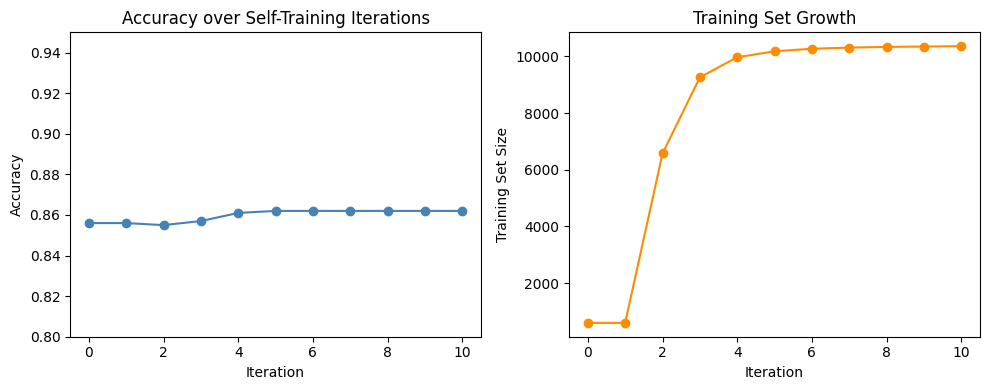

In [48]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(accuracies, marker='o', color='steelblue')
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy over Self-Training Iterations")
plt.ylim(0.8, 0.95)

plt.subplot(1, 2, 2)
plt.plot(sizes, marker='o', color='darkorange')
plt.xlabel("Iteration")
plt.ylabel("Training Set Size")
plt.title("Training Set Growth")

plt.tight_layout()
plt.show()

In [49]:
clf_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_final.fit(X_lab, y_lab)

y_pred_final = clf_final.predict(X_test)

print("Before adding the pseudo labels (5% labels only):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_weak), 3))
print()
print("After adding the pseudo labels:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print()
print(classification_report(y_test, y_pred_final))

Before adding the pseudo labels (5% labels only):
Accuracy: 0.856

After adding the pseudo labels:
Accuracy: 0.862

              precision    recall  f1-score   support

    Business       0.84      0.80      0.82       750
    Sci/Tech       0.82      0.82      0.82       750
      Sports       0.90      0.96      0.93       750
       World       0.88      0.87      0.87       750

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



### 5.2 FixMatch

In the previous pseudo labeling approach, the method used confidence alone to decide which pseudo-labels to trust.

FixMatch adds a second condition: **consistency**.

The idea:
> Take the same article, perturb it two ways. If the model is confident on the weak perturbation AND the strong perturbation agrees, only then do we use it as a pseudo-label.

For text we simulate perturbations by randomly dropping words:
- Weak augmentation: drop 10% of words
- Strong augmentation: drop 40% of words

The training loss has two parts:
- Supervised loss on the 600 labelled examples (same as before)
- Unsupervised loss on confident AND consistent pseudo-labels

In [50]:
def weak_augment(tokens, drop_prob=0.1):
    augmented = [w for w in tokens if np.random.rand() > drop_prob]
    return augmented if len(augmented) > 0 else tokens

def strong_augment(tokens, drop_prob=0.4):
    augmented = [w for w in tokens if np.random.rand() > drop_prob]
    return augmented if len(augmented) > 0 else tokens

np.random.seed(RANDOM_STATE)

# precompute weak and strong augmented vectors for all unlabelled articles
X_unlab_weak   = np.array([article_vector(weak_augment(t),   w2v_model) for t in X_train_tokens[len(X_labelled):]])
X_unlab_strong = np.array([article_vector(strong_augment(t), w2v_model) for t in X_train_tokens[len(X_labelled):]])

print("Weak augmented matrix shape:  ", X_unlab_weak.shape)
print("Strong augmented matrix shape:", X_unlab_strong.shape)

Weak augmented matrix shape:   (11400, 100)
Strong augmented matrix shape: (11400, 100)


In [51]:
THRESHOLD    = 0.80
N_ITERATIONS = 10

X_lab_fm = X_labelled.copy()
y_lab_fm = y_labelled.copy()

accuracies_fm = [round(accuracy_score(y_test, y_pred_weak), 3)]
sizes_fm      = [len(X_lab_fm)]

kept_weak   = X_unlab_weak.copy()
kept_strong = X_unlab_strong.copy()

print(f"Iteration 0 | Training size: {len(X_lab_fm):5d} | Accuracy: {accuracies_fm[0]}")

for i in range(1, N_ITERATIONS + 1):
    clf_fm = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf_fm.fit(X_lab_fm, y_lab_fm)

    acc = round(accuracy_score(y_test, clf_fm.predict(X_test)), 3)

    # step 1: get predictions on weak augmentations
    probs_weak    = clf_fm.predict_proba(kept_weak)
    max_probs     = probs_weak.max(axis=1)                      # article 1: [0.85, 0.05, 0.08, 0.02]  -> max_prob = 0.85
    pseudo_labels = clf_fm.classes_[probs_weak.argmax(axis=1)]

    # step 2: get predictions on strong augmentations
    probs_strong       = clf_fm.predict_proba(kept_strong)
    strong_predictions = clf_fm.classes_[probs_strong.argmax(axis=1)]

    # step 3: keep only confident AND consistent
    confident  = max_probs >= THRESHOLD
    consistent = pseudo_labels == strong_predictions
    selected   = confident & consistent

    if selected.sum() == 0:
        print(f"Iteration {i} | No confident+consistent predictions found, stopping early.")
        break

    # step 4: add selected pseudo-labels to training set
    X_lab_fm = np.vstack([X_lab_fm, kept_weak[selected]])
    y_lab_fm = np.concatenate([y_lab_fm, pseudo_labels[selected]])

    # step 5: remove selected from unlabelled pool
    kept_weak   = kept_weak[~selected]
    kept_strong = kept_strong[~selected]

    accuracies_fm.append(acc)
    sizes_fm.append(len(X_lab_fm) - selected.sum())

    print(f"Iteration {i} | Training size: {len(X_lab_fm) - selected.sum():5d} | Selected: {selected.sum():4d} | New size: {len(X_lab_fm):5d} | Accuracy: {acc}")

Iteration 0 | Training size:   600 | Accuracy: 0.856
Iteration 1 | Training size:   600 | Selected: 5945 | New size:  6545 | Accuracy: 0.856
Iteration 2 | Training size:  6545 | Selected: 2590 | New size:  9135 | Accuracy: 0.856
Iteration 3 | Training size:  9135 | Selected:  699 | New size:  9834 | Accuracy: 0.859
Iteration 4 | Training size:  9834 | Selected:  196 | New size: 10030 | Accuracy: 0.86
Iteration 5 | Training size: 10030 | Selected:   64 | New size: 10094 | Accuracy: 0.861
Iteration 6 | Training size: 10094 | Selected:   38 | New size: 10132 | Accuracy: 0.863
Iteration 7 | Training size: 10132 | Selected:   25 | New size: 10157 | Accuracy: 0.863
Iteration 8 | Training size: 10157 | Selected:   20 | New size: 10177 | Accuracy: 0.862
Iteration 9 | Training size: 10177 | Selected:   21 | New size: 10198 | Accuracy: 0.862
Iteration 10 | Training size: 10198 | Selected:    4 | New size: 10202 | Accuracy: 0.862


In [52]:
clf_fm_final = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_fm_final.fit(X_lab_fm, y_lab_fm)
y_pred_fm = clf_fm_final.predict(X_test)

print("Before any semi-supervised training:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_weak), 3))
print()
print("After self-training:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print()
print("After FixMatch:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_fm), 3))
print()
print(classification_report(y_test, y_pred_fm))

Before any semi-supervised training:
Accuracy: 0.856

After self-training:
Accuracy: 0.862

After FixMatch:
Accuracy: 0.862

              precision    recall  f1-score   support

    Business       0.84      0.80      0.82       750
    Sci/Tech       0.83      0.83      0.83       750
      Sports       0.90      0.96      0.93       750
       World       0.87      0.87      0.87       750

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



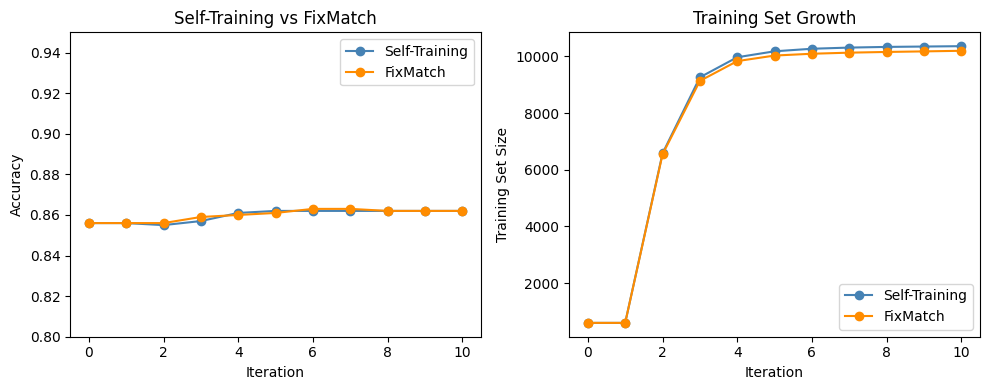

In [53]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(accuracies,    marker='o', color='steelblue',  label='Self-Training')
plt.plot(accuracies_fm, marker='o', color='darkorange', label='FixMatch')
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Self-Training vs FixMatch")
plt.legend()
plt.ylim(0.80, 0.95)

plt.subplot(1, 2, 2)
plt.plot(sizes,    marker='o', color='steelblue',  label='Self-Training')
plt.plot(sizes_fm, marker='o', color='darkorange', label='FixMatch')
plt.xlabel("Iteration")
plt.ylabel("Training Set Size")
plt.title("Training Set Growth")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Unsupervised Learning

So far we used at least some labels. Now let's assume we do not have any available labeled data.

We only have the Word2Vec vectors.

### 6.1. K-Means Clustering

The question is:

> Can the geometry of the vectors alone recover the 4 news topics?

We run K-Means with k=4 and see if the clusters align with World, Sports, Business, Sci/Tech.

In [54]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train)

cluster_labels = kmeans.labels_

print("Cluster sizes:")
for k in range(4):
    print(f"  Cluster {k}: {(cluster_labels == k).sum()} articles")

Cluster sizes:
  Cluster 0: 3081 articles
  Cluster 1: 3263 articles
  Cluster 2: 4149 articles
  Cluster 3: 1507 articles


#### What is inside each cluster?

K-Means found 4 groups but has no idea what they mean. Let's peek inside each cluster and see which true labels dominate.

In [55]:
cluster_df = pd.DataFrame({
    "cluster": cluster_labels,
    "true_label": y_train
})

for k in range(4):
    print(f"Cluster {k}:")
    counts = cluster_df[cluster_df["cluster"] == k]["true_label"].value_counts()
    for label, count in counts.items():
        pct = round(100 * count / counts.sum(), 1)
        print(f"  {label:10s}: {count:4d} ({pct}%)")
    print()

Cluster 0:
  World     : 2583 (83.8%)
  Sci/Tech  :  229 (7.4%)
  Business  :  218 (7.1%)
  Sports    :   51 (1.7%)

Cluster 1:
  Sports    : 2894 (88.7%)
  World     :  184 (5.6%)
  Sci/Tech  :  117 (3.6%)
  Business  :   68 (2.1%)

Cluster 2:
  Sci/Tech  : 2510 (60.5%)
  Business  : 1415 (34.1%)
  World     :  170 (4.1%)
  Sports    :   54 (1.3%)

Cluster 3:
  Business  : 1299 (86.2%)
  Sci/Tech  :  144 (9.6%)
  World     :   63 (4.2%)
  Sports    :    1 (0.1%)



In [56]:
from scipy.optimize import linear_sum_assignment

def clustering_accuracy(true_labels, cluster_labels, class_names):
    # build a confusion matrix between clusters and true labels
    n = len(class_names)
    label_to_idx = {label: i for i, label in enumerate(class_names)}
    true_idx = np.array([label_to_idx[l] for l in true_labels])

    cost_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost_matrix[i, j] = np.sum((cluster_labels == i) & (true_idx == j))

    # lets see what the cost matrix looks like:
    cost_df = pd.DataFrame(
        cost_matrix.astype(int),
        index=[f"Cluster {i}" for i in range(n)],
        columns=class_names
    )
    print("Cost matrix (rows=clusters, cols=true labels):")
    print(cost_df.to_string())
    print()

    # hungarian algorithm finds best cluster to label mapping
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)

    total_correct = cost_matrix[row_ind, col_ind].sum()
    accuracy = round(total_correct / len(true_labels), 3)

    mapping = {row_ind[i]: class_names[col_ind[i]] for i in range(n)}
    return accuracy, mapping

acc, mapping = clustering_accuracy(y_train, cluster_labels, CLASS_NAMES)

print("Cluster to label mapping:")
for cluster, label in mapping.items():
    print(f"  Cluster {cluster} -> {label}")
print()
print("K-Means clustering accuracy:", acc)

Cost matrix (rows=clusters, cols=true labels):
           World  Sports  Business  Sci/Tech
Cluster 0   2583      51       218       229
Cluster 1    184    2894        68       117
Cluster 2    170      54      1415      2510
Cluster 3     63       1      1299       144

Cluster to label mapping:
  Cluster 0 -> World
  Cluster 1 -> Sports
  Cluster 2 -> Sci/Tech
  Cluster 3 -> Business

K-Means clustering accuracy: 0.774


#### Visualizing the Clusters with t-SNE

K-Means works in 100 dimensions which we cannot visualize directly.

t-SNE compresses those 100 dimensions down to 2 so we can plot them. It tries to keep articles that are close in 100D still close in 2D.

We plot twice:
- Left: colored by K-Means cluster assignment
- Right: colored by true label

If the clusters align well, the two plots should look similar.

In [57]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=50, n_iter=1000)
X_2d = tsne.fit_transform(X_train)

print("Done!")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Done!


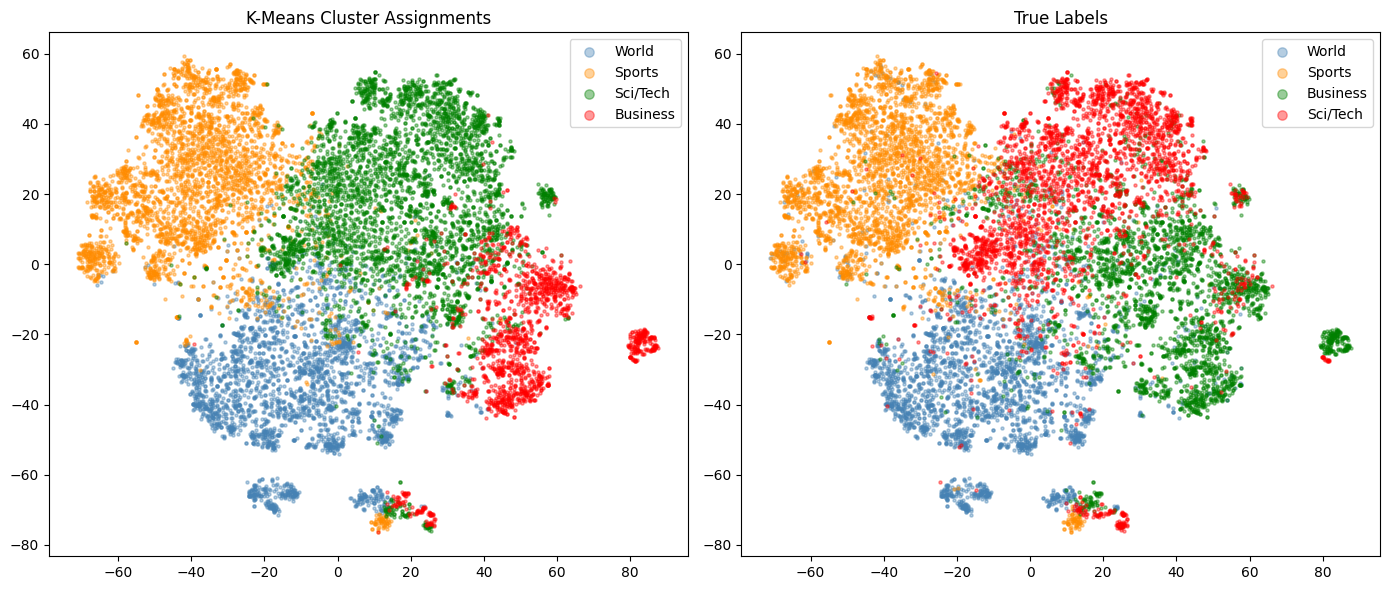

In [58]:
colors = ['steelblue', 'darkorange', 'green', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left plot: K-Means clusters
for k in range(4):
    idx = cluster_labels == k
    axes[0].scatter(X_2d[idx, 0], X_2d[idx, 1],
                   c=colors[k], label=mapping[k], alpha=0.4, s=5)
axes[0].set_title("K-Means Cluster Assignments")
axes[0].legend(markerscale=3)

# right plot: true labels
label_to_color = {label: colors[i] for i, label in enumerate(CLASS_NAMES)}
for label in CLASS_NAMES:
    idx = y_train == label
    axes[1].scatter(X_2d[idx, 0], X_2d[idx, 1],
                   c=label_to_color[label], label=label, alpha=0.4, s=5)
axes[1].set_title("True Labels")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

### 6.2. Gaussian Mixture Models

K-Means makes hard assignments - every article belongs to exactly one cluster.

But what about articles that sit between two topics? Like a tech company's earnings report - is it Business or Sci/Tech?

GMM gives every article a **soft assignment**: a probability of belonging to each cluster.

> Instead of "this article is Business", GMM says "this article is 70% Business and 30% Sci/Tech"

These probabilities are called **responsibilities**.

Instead of representing each cluster as a single point like K-Means, GMM represents each cluster as a **Gaussian distribution** with two properties:

- **Mean** - the center of the cluster, same as K-Means centroid
- **Covariance** - the shape and spread of the cluster

This means clusters can be elongated, rotated, wide or narrow - much more flexible than K-Means which assumes all clusters are spherical and equal sized.

### How does GMM assign articles to clusters?

For each article GMM computes the probability that it belongs to each cluster using Bayes' rule:

**P(cluster k | article) = P(article | cluster k) x P(cluster k) / P(article)**

Breaking this down:

- **P(article | cluster k)** — how well does this article fit inside Gaussian k? Articles that sit close to the mean and within the shape of Gaussian k get a high score here
- **P(cluster k)** — how large is cluster k relative to the others? Larger clusters get a higher prior probability
- **P(article)** — just a normalizing constant that makes all 4 probabilities sum to 1

So an article gets high responsibility for cluster k if it fits well within that Gaussian's shape. This is the **E step** of the EM algorithm — given the current Gaussian shapes, compute responsibilities for every article.

Then in the **M step**, we use those responsibilities to update the Gaussian shapes (mean and covariance) and repeat until convergence.

In [59]:
gmm = GaussianMixture(n_components=4, random_state=RANDOM_STATE, n_init=5)
gmm.fit(X_train)

gmm_labels = gmm.predict(X_train)
responsibilities = gmm.predict_proba(X_train)

acc_gmm, mapping_gmm = clustering_accuracy(y_train, gmm_labels, CLASS_NAMES)
print("GMM clustering accuracy:", acc_gmm)
print()
print("Cluster to label mapping:")
for cluster, label in mapping_gmm.items():
    print(f"  Cluster {cluster} -> {label}")

Cost matrix (rows=clusters, cols=true labels):
           World  Sports  Business  Sci/Tech
Cluster 0   2585      33       214       209
Cluster 1    178    2889        73        86
Cluster 2    107      12      1998       276
Cluster 3    130      66       715      2429

GMM clustering accuracy: 0.825

Cluster to label mapping:
  Cluster 0 -> World
  Cluster 1 -> Sports
  Cluster 2 -> Business
  Cluster 3 -> Sci/Tech


### Reading the Responsibility Table

Let's look at 10 articles and their soft assignments. Each row sums to 1.

Articles deep inside a cluster will have one probability close to 1.
Articles near a boundary will be split across two clusters.

In [60]:
resp_df = pd.DataFrame(
    responsibilities,
    columns=[f"Cluster {k} ({mapping_gmm[k]})" for k in range(4)]
)
resp_df["true_label"] = y_train

# show 5 confident examples and 5 uncertain ones
max_prob = responsibilities.max(axis=1)
confident_idx  = np.argsort(max_prob)[-5:][::-1]
uncertain_idx  = np.argsort(max_prob)[:5]

print("5 most confident assignments:")
print(resp_df.iloc[confident_idx].round(3).to_string())
print()
print("5 most uncertain assignments:")
print(resp_df.iloc[uncertain_idx].round(3).to_string())

5 most confident assignments:
    Cluster 0 (World)  Cluster 1 (Sports)  Cluster 2 (Business)  Cluster 3 (Sci/Tech) true_label
16                0.0                 0.0                   1.0                   0.0   Business
17                0.0                 1.0                   0.0                   0.0     Sports
18                0.0                 0.0                   1.0                   0.0   Business
21                0.0                 0.0                   1.0                   0.0   Business
22                1.0                 0.0                   0.0                   0.0      World

5 most uncertain assignments:
       Cluster 0 (World)  Cluster 1 (Sports)  Cluster 2 (Business)  Cluster 3 (Sci/Tech) true_label
8092               0.296               0.003                 0.367                 0.334      World
5987               0.422               0.000                 0.345                 0.233   Business
10808              0.191               0.307             